# Sentiment Analysis System

In this Notebook we use a labelled dataset of text data. We clean and preprocess
the data, use the data to train multiple machine learning algorithms, compare 
model performance, and select and save the best performing model to use in our 
final system.

## Import libraries

In [15]:
# Import Libraries

import pandas as pd 
import numpy as np
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (accuracy_score, 
                             precision_score, 
                             recall_score, f1_score, 
                             classification_report, 
                             confusion_matrix,
                             ConfusionMatrixDisplay
                             )
from sklearn.model_selection import GridSearchCV

import joblib

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Mahlasela\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Mahlasela\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Mahlasela\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## Load dataset

In [16]:
# Import full dataset
sentiment_data = pd.read_csv(
    "Sentiment140.csv",
    encoding="latin-1",
    header=None
)

# Display data sample
sentiment_data.head()

,0,1,2,3,4,5
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


## Explore data

In [17]:
# Drop unnecessary columns
sentiment_data.drop([1, 2, 3, 4], axis= 1, inplace= True)

sentiment_data.head()

,0,5
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,is upset that he can't update his Facebook by ...
2,0,@Kenichan I dived many times for the ball. Man...
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all...."


We dropped the columns that are not necessary to train and test our machine 
learning algorithms.

In [18]:
# Name the columns appropriately
sentiment_data.columns = ["sentiment", "text"]
sentiment_data = sentiment_data[["text", "sentiment"]]

sentiment_data.head()

,text,sentiment
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",0
1,is upset that he can't update his Facebook by ...,0
2,@Kenichan I dived many times for the ball. Man...,0
3,my whole body feels itchy and like its on fire,0
4,"@nationwideclass no, it's not behaving at all....",0


We gave our columns appropriate names to make the data easier to interpret.

In [19]:
# Shape of our dataset
sentiment_data.shape

(1600000, 2)

Our data consists of 1 600 000 rows and 2 columns.

In [20]:
# Check for missing values
sentiment_data.isnull().sum()

text         0
sentiment    0
dtype: int64

We have no missinig values in our dataset.

In [21]:
# convert labels
sentiment_data["sentiment"] = sentiment_data["sentiment"].replace({
    4: 1
})

sentiment_data.sample(5)

,text,sentiment
22707,"god i'm tired really fed up too, theres nothi...",0
171228,@courtneyreece I know how you feel. My head is...,0
506858,@MiguelSeagull im stuck doing this for atleast...,0
315635,@syeelamarlina s-ma... my hp telah meninggal d...,0
984621,Going to sleep finally hung up the phone with ...,1


We convert our labels to 0 and 1 to represent negative and positive more clearly.

In [22]:
# Check for duplicate columns
sentiment_data.duplicated().sum()

16309

In [23]:
# Drop duplicate cloumns
sentiment_data = sentiment_data.drop_duplicates()

# Check for duplicate columns
sentiment_data.duplicated().sum()

0

We found 16309 duplicate columns and removed them

In [24]:
sentiment_data.shape

(1583691, 2)

## Text preprocesing

In [25]:
# Create the stop words set and lemmatizer
stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

In [26]:
# Create the cleaning function

def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove user mentions
    text = re.sub(r'@\w+', '', text)

    # Remove the # symbol but keep the word
    text = re.sub(r'#', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove extra spaces
    text = " ".join(text.split())

    # Tokenize
    words = text.split()

    # Remove stop words and lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

Our function cleans our data of unwanted featured such as URLs and symbols

In [27]:
# Clean the dataset
sentiment_data["clean_text"] = sentiment_data["text"].apply(clean_text)

# Display sample of original and cleaned data
sentiment_data[["text", "clean_text"]].head(10)

,text,clean_text
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",thats bummer shoulda got david carr third day
1,is upset that he can't update his Facebook by ...,upset cant update facebook texting might cry r...
2,@Kenichan I dived many times for the ball. Man...,dived many time ball managed save rest go bound
3,my whole body feels itchy and like its on fire,whole body feel itchy like fire
4,"@nationwideclass no, it's not behaving at all....",behaving im mad cant see
5,@Kwesidei not the whole crew,whole crew
6,Need a hug,need hug
7,@LOLTrish hey long time no see! Yes.. Rains a...,hey long time see yes rain bit bit lol im fine...
8,@Tatiana_K nope they didn't have it,nope didnt
9,@twittera que me muera ?,que muera


The cleaned text does not contain any of the unwanted features

In [28]:
# Checking for empty rows
(sentiment_data["clean_text"] == "").sum()

7038

In [29]:
# Removing empty rows
sentiment_data = sentiment_data[sentiment_data["clean_text"] != ""]

# Checking for empty rows
(sentiment_data["clean_text"] == "").sum()

0

We found 7038 empty rows and removed them

## Data Analysis

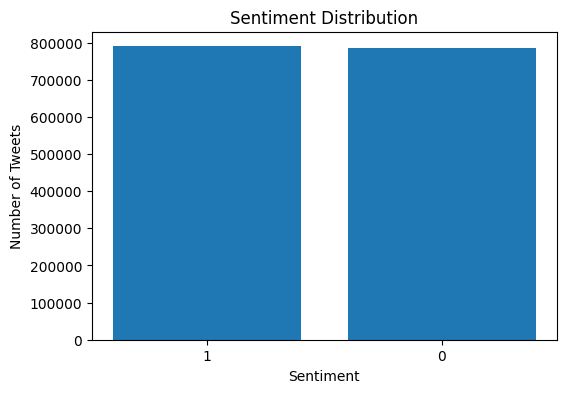

In [30]:
# Visualize number of tweets in each sentiment
sentiment_counts = sentiment_data["sentiment"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(
    sentiment_counts.index.astype(str),
    sentiment_counts.values
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")

plt.show()

We see that the dataset is quite balanced between positive and negative sentiments.

In [31]:
# Find word counts
sentiment_data["word_count"] = sentiment_data["clean_text"].apply(
    lambda x: len(x.split()))

sentiment_data[["clean_text","word_count"]].head()

,clean_text,word_count
0,thats bummer shoulda got david carr third day,8
1,upset cant update facebook texting might cry r...,12
2,dived many time ball managed save rest go bound,9
3,whole body feel itchy like fire,6
4,behaving im mad cant see,5


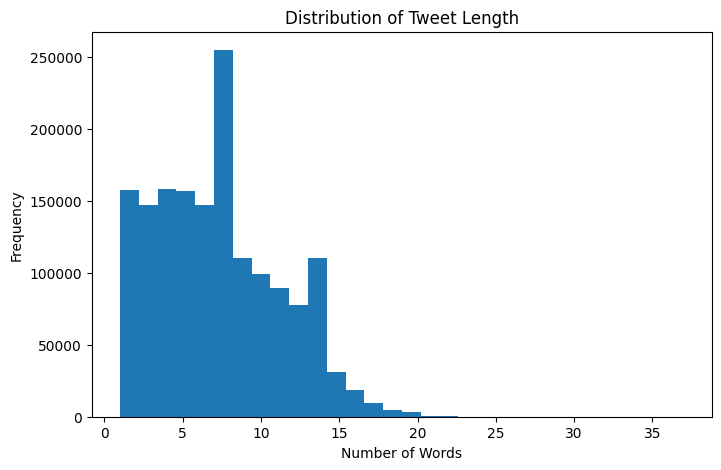

In [32]:
# Word count distribution
plt.figure(figsize=(8,5))

plt.hist(sentiment_data["word_count"], bins=30)

plt.title("Distribution of Tweet Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

We see that most tweets contain less than 10 words

In [33]:
# Combine all cleaned tweets
all_words = " ".join(sentiment_data["clean_text"]).split()

# Count all the words
word_counts = Counter(all_words)

# Display most common words
print('Most Common Words:')
word_counts.most_common(20)

Most Common Words:


[('im', 176927),
 ('day', 103140),
 ('good', 88306),
 ('get', 85601),
 ('like', 78855),
 ('go', 76939),
 ('u', 67062),
 ('love', 66614),
 ('dont', 66499),
 ('today', 65749),
 ('work', 65224),
 ('going', 63647),
 ('time', 63447),
 ('cant', 62208),
 ('got', 60468),
 ('one', 55673),
 ('back', 55560),
 ('lol', 55139),
 ('know', 53089),
 ('really', 49213)]

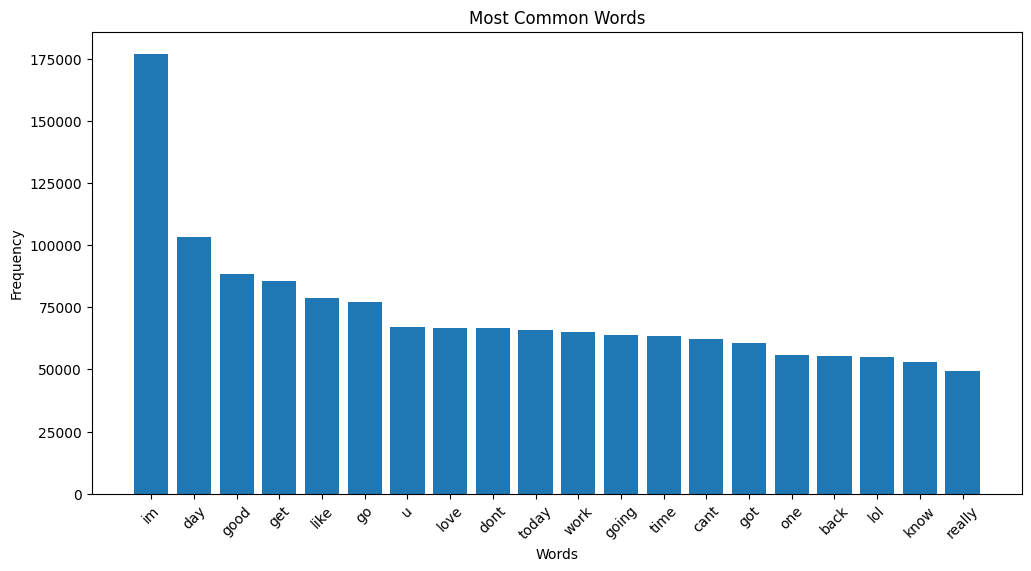

In [34]:
# Plot most common words
top_words = word_counts.most_common(20)

words = [word for word, count in top_words]
counts = [count for word, count in top_words]

plt.figure(figsize=(12,6))

plt.bar(words, counts)

plt.xticks(rotation=45)

plt.title("Most Common Words")

plt.xlabel("Words")

plt.ylabel("Frequency")

plt.show()

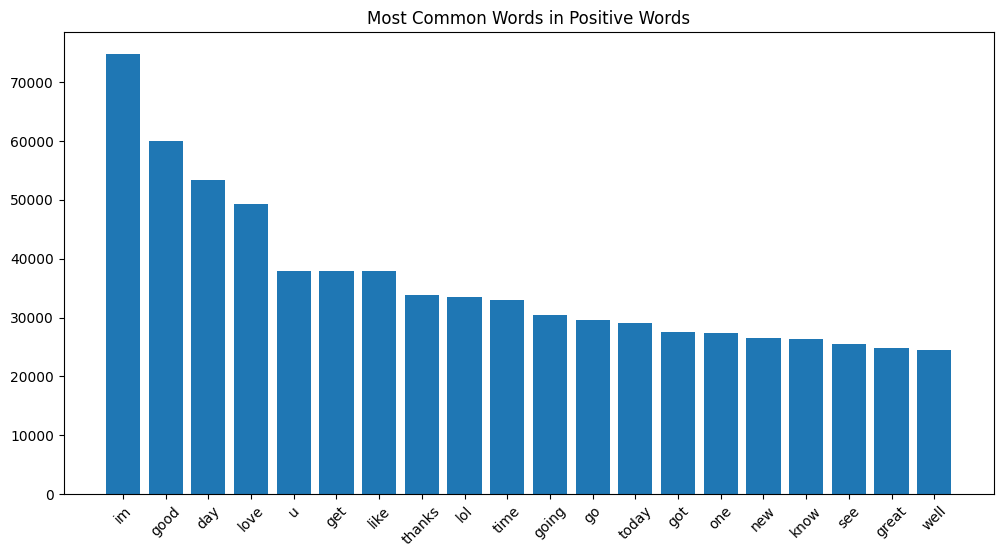

In [35]:
# Most common positive words
positive_text = " ".join(
    sentiment_data[sentiment_data["sentiment"] == 1]["clean_text"]
).split()

positive_counts = Counter(positive_text)

positive_counts.most_common(20)

# Plot the words
top_positive = positive_counts.most_common(20)

words = [word for word, count in top_positive]
counts = [count for word, count in top_positive]

plt.figure(figsize=(12,6))

plt.bar(words, counts)

plt.xticks(rotation=45)

plt.title("Most Common Words in Positive Words")

plt.show()

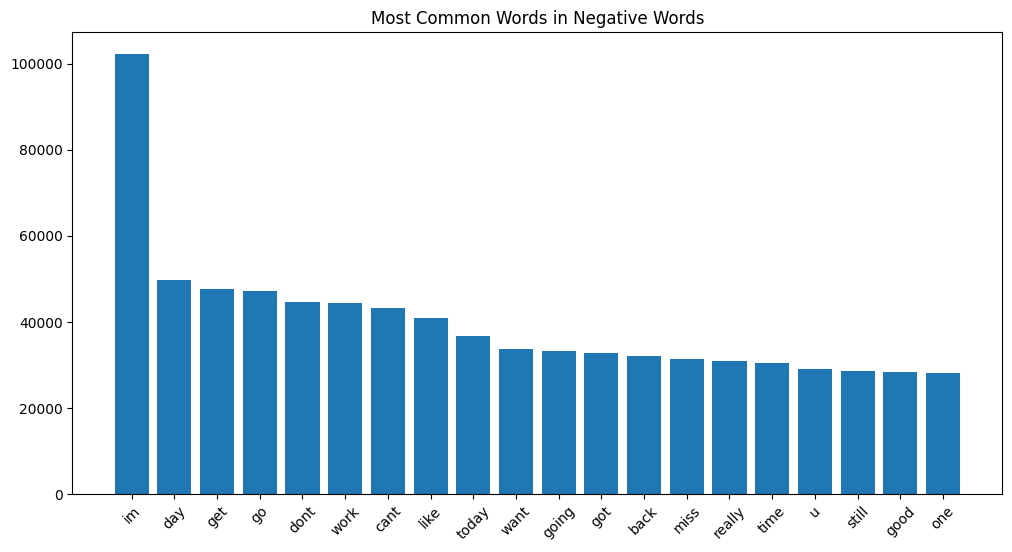

In [36]:
# Most common negative words
negative_text = " ".join(
    sentiment_data[sentiment_data["sentiment"] == 0]["clean_text"]
).split()

negative_counts = Counter(negative_text)

negative_counts.most_common(20)

# Plot the words
top_negative = negative_counts.most_common(20)

words = [word for word, count in top_negative]
counts = [count for word, count in top_negative]

plt.figure(figsize=(12,6))

plt.bar(words, counts)

plt.xticks(rotation=45)

plt.title("Most Common Words in Negative Words")

plt.show()

## Splitting the Dataset

In [37]:
# Independent variables
X = sentiment_data["clean_text"]

# Dependent variable
y = sentiment_data["sentiment"]

In [38]:
# Create the test set
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

In [39]:
# Create the training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.1765,
    random_state=42,
    stratify=y_train_val
)

In [40]:
# Check the shapes of the sets
print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (1103617,)
Validation set: (236538,)
Test set: (236498,)


The data was split into the training, validation and test sets

## Feature Engineering

In [41]:
# Create thr vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.95
)

In [42]:
# Fit the vectorizer to the training data
X_train = tfidf.fit_transform(X_train)

In [43]:
# Transform validation set
X_val = tfidf.transform(X_val)

# Transform the test set
X_test = tfidf.transform(X_test)

In [44]:
print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Training: (1103617, 5000)
Validation: (236538, 5000)
Test: (236498, 5000)


In [45]:
# Sample of learned features
feature_names = tfidf.get_feature_names_out()

print(feature_names[:30])

['aaron' 'ab' 'able' 'able get' 'able go' 'able make' 'absolutely' 'abt'
 'ac' 'accent' 'accept' 'access' 'accident' 'accidentally' 'accomplished'
 'according' 'account' 'ace' 'ache' 'aching' 'acoustic' 'across' 'act'
 'acting' 'action' 'active' 'activity' 'actor' 'actual' 'actually']


In [46]:
# Save the vectorizer
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

## Model Training

In [47]:
# Random state to ensure reproducibility
r = 42

# Results list
results = []

Training process:

In [48]:
# Chosen models
models = {
    "Naive Bayes": MultinomialNB(),

    "Logistic Regression": LogisticRegression(
        max_iter = 1000,
        random_state = r
    ),

    "Linear SVM": LinearSVC(
        random_state = r
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators = 100,
        random_state = r,
        n_jobs = -1
    )
}

We have chosen to test Naive Bayes, Logistic Regression, SVM, and Random Forest

In [49]:
# Train and evaluate the models
trained_models = {}

for name, model in models.items():

    print(f"\nTraining {name}...")

    # Train
    model.fit(X_train, y_train)

    # Save trained model
    trained_models[name] = model

    # Predict on validation set
    predictions = model.predict(X_val)

    # Metrics
    accuracy = accuracy_score(y_val, predictions)

    precision = precision_score(
        y_val,
        predictions,
        average="weighted"
    )

    recall = recall_score(
        y_val,
        predictions,
        average="weighted"
    )

    f1 = f1_score(
        y_val,
        predictions,
        average="weighted"
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    print(f"Accuracy : {accuracy:.4f}")


Training Naive Bayes...
Accuracy : 0.7629

Training Logistic Regression...
Accuracy : 0.7772

Training Linear SVM...
Accuracy : 0.7765

Training Random Forest...
Accuracy : 0.7680


Model Comparison:

In [50]:
# Comparison table
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
1,Logistic Regression,0.777169,0.777735,0.777169,0.777040
2,Linear SVM,0.776471,0.777287,0.776471,0.776289
3,Random Forest,0.767982,0.767983,0.767982,0.767982
0,Naive Bayes,0.762884,0.762954,0.762884,0.762862


We see that the Logistic Regression model performed the best when judged by 
accuracy and F1 score

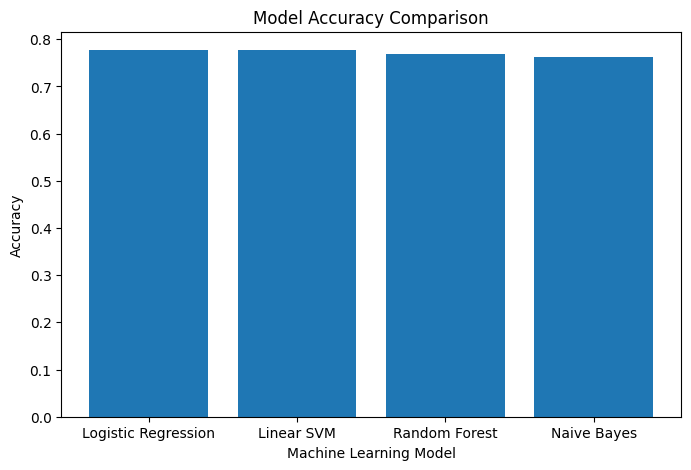

In [51]:
# Accuracy plot
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["Accuracy"]
)

plt.title("Model Accuracy Comparison")

plt.xlabel("Machine Learning Model")

plt.ylabel("Accuracy")

plt.show()

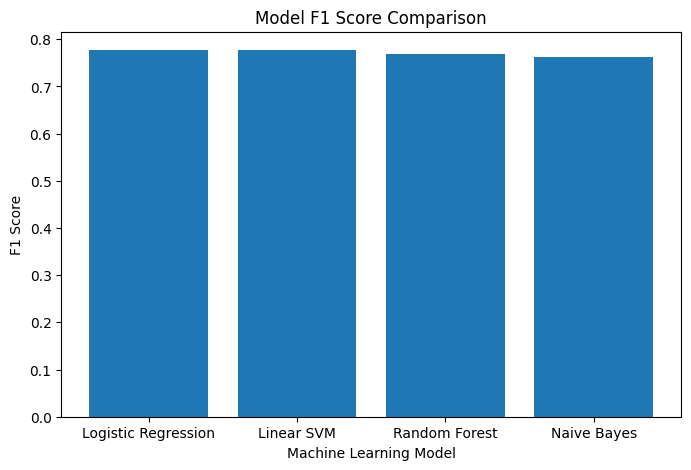

In [52]:
# F! Score plot
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["F1 Score"]
)

plt.title("Model F1 Score Comparison")

plt.xlabel("Machine Learning Model")

plt.ylabel("F1 Score")

plt.show()

Logistic Regression Confusion Matrix:

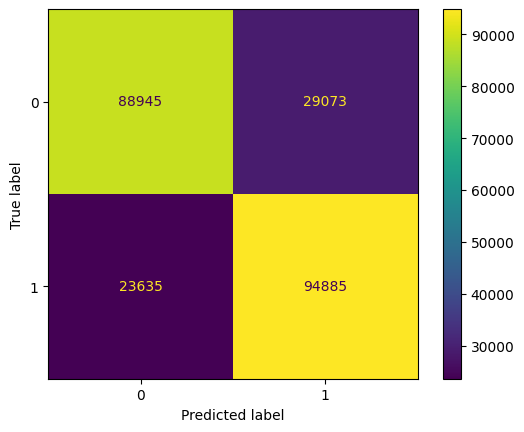

In [53]:
best_model = trained_models["Logistic Regression"]

predictions = best_model.predict(X_val)

cm = confusion_matrix(y_val, predictions)

ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot()

plt.show()

We see that the model correctly labelled negative sentiment 88 945 times and 
incorrectly lablled positive sentiment as negative 23 635 times. We also see that 
the model correctly labelled positive sentiment 94 885 times and incorrectly 
labelled negative sentiment as positive 29 073 times.

Selecting the best model:

In [54]:
best_model_name = results_df.iloc[0]["Model"]

print(best_model_name)

Logistic Regression


In [55]:
best_model = trained_models[best_model_name]

## Hyperparameter Tuning

In [56]:
# Tuning parameter
lr_parameters = {
    "C": [0.01, 0.1, 1, 10, 100]
}

In [57]:
# Define grid search
lr_grid = GridSearchCV(
    estimator=LogisticRegression(
        max_iter = 1000,
        random_state = r
    ),
    param_grid = lr_parameters,
    cv = 3,
    scoring = "f1",
    n_jobs = -1,
    verbose = 2
)

In [58]:
# Perform grid sarch
print("Logistic Regression hyperparameter tuning...")

lr_grid.fit(X_train, y_train)

print("Tuning complete.")

Logistic Regression hyperparameter tuning...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Tuning complete.


In [59]:
# Best parameters
print("Best parameters:")
print(lr_grid.best_params_)

Best parameters:
{'C': 1}


The best parameter shows us that the model performs best with modest regularization

In [60]:
# Best model
best_lr_model = lr_grid.best_estimator_

Predicting on the Tuned Model:

In [61]:
y_val_pred_lr = best_lr_model.predict(X_val)

# Define performance metrics
lr_val_accuracy = accuracy_score(y_val, y_val_pred_lr)

lr_val_precision = precision_score(
    y_val,
    y_val_pred_lr,
    average = "weighted"
)

lr_val_recall = recall_score(
    y_val,
    y_val_pred_lr,
    average = "weighted"
)

lr_val_f1 = f1_score(
    y_val,
    y_val_pred_lr,
    average = "weighted"
)

In [62]:
print("Tuned Logistic Regression:\n")
print(f"Accuracy:  {lr_val_accuracy:.4f}")
print(f"Precision: {lr_val_precision:.4f}")
print(f"Recall:    {lr_val_recall:.4f}")
print(f"F1 Score:  {lr_val_f1:.4f}")

Tuned Logistic Regression:

Accuracy:  0.7772
Precision: 0.7777
Recall:    0.7772
F1 Score:  0.7770


## Testing on Unseed Data

In [63]:
# Predict on the test set
y_test_pred = best_lr_model.predict(X_test)

In [64]:
# Define performance metrics
test_accuracy = accuracy_score(y_test, y_test_pred)

test_precision = precision_score(
    y_test,
    y_test_pred,
    average="weighted"
)

test_recall = recall_score(
    y_test,
    y_test_pred,
    average="weighted"
)

test_f1 = f1_score(
    y_test,
    y_test_pred,
    average="weighted"
)

In [65]:
print("Final Logistic Regression Test Results:\n")
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1 Score:  {test_f1:.4f}")

Final Logistic Regression Test Results:

Accuracy:  0.7779
Precision: 0.7784
Recall:    0.7779
F1 Score:  0.7778


In [66]:
# Generate classification report
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["Negative", "Positive"]
    )
)

              precision    recall  f1-score   support

    Negative       0.79      0.76      0.77    117998
    Positive       0.77      0.80      0.78    118500

    accuracy                           0.78    236498
   macro avg       0.78      0.78      0.78    236498
weighted avg       0.78      0.78      0.78    236498



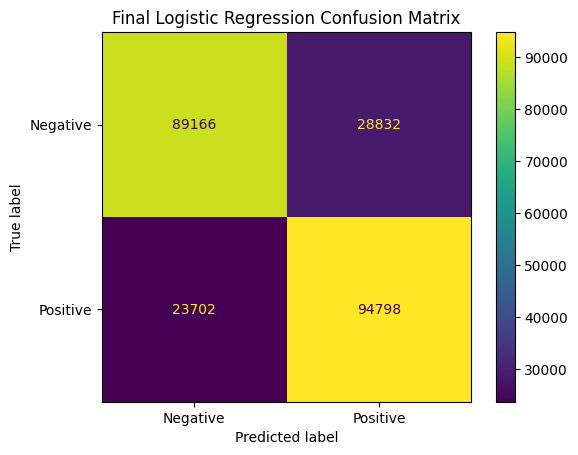

In [67]:
# Generate confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=["Negative", "Positive"]
)

plt.title("Final Logistic Regression Confusion Matrix")
plt.show()

We see that the model correctly labelled negative sentiment 89 166 times and 
incorrectly labelled positive sentiment as negative 23 702 times. We also see 
that it also correctly labelled positive sentiment 94 798 times and mislabelled 
positive sentiment as negative 28 832 times.

In [68]:
final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Score": [
        test_accuracy,
        test_precision,
        test_recall,
        test_f1
    ]
})

final_results

,Metric,Score
0,Accuracy,0.777867
1,Precision,0.778371
2,Recall,0.777867
3,F1 Score,0.777752


Saving the model:

In [69]:
# Save the model
joblib.dump(
    best_lr_model,
    "sentiment_model.pkl"
)

['sentiment_model.pkl']

## Building Prediction Function

In [70]:
# Define the function
def predict_sentiment(text):
    
    # Clean the input text
    cleaned_text = clean_text(text)
    
    # Convert text to TF-IDF features
    text_features = tfidf.transform([cleaned_text])
    
    # Make prediction
    prediction = best_lr_model.predict(text_features)[0]
    
    # Convert numerical prediction to sentiment
    if prediction == 1:
        sentiment = "Positive"
    else:
        sentiment = "Negative"
    
    return sentiment

In [74]:
# Test prediction function
predict_sentiment("I absolutely love my new car!")

'Positive'

In [ ]:
predict_sentiment("That was the worst movie ever.")

'Negative'

In [77]:
test_sentences = [
    "I absolutely love my new car",
    "This is the worst product I have ever bought.",
    "The new Spider-Man movie was fantastic.",
    "I'm extremely disappointed with the service.",
]

for sentence in test_sentences:
    prediction = predict_sentiment(sentence)
    
    print(f"Text: {sentence}")
    print(f"Sentiment: {prediction}")
    print("\n")

Text: I absolutely love my new car
Sentiment: Positive


Text: This is the worst product I have ever bought.
Sentiment: Negative


Text: The new Spider-Man movie was fantastic.
Sentiment: Positive


Text: I'm extremely disappointed with the service.
Sentiment: Negative




## Adding Confidence to the Prediction

In [78]:
# Modified predictioon function
def predict_sentiment(text):
    
    # Clean the input
    cleaned_text = clean_text(text)
    
    # Convert to TF-IDF
    text_features = tfidf.transform([cleaned_text])
    
    # Prediction
    prediction = best_lr_model.predict(text_features)[0]
    
    # Probability
    probabilities = best_lr_model.predict_proba(text_features)[0]
    
    # Get probability for predicted class
    confidence = probabilities[prediction]
    
    # Convert prediction to label
    if prediction == 1:
        sentiment = "Positive"
    else:
        sentiment = "Negative"
    
    return sentiment, confidence

In [79]:
# Test modified function
sentiment, confidence = predict_sentiment(
    "I absolutely love my new car!"
)

print("Sentiment:", sentiment)
print(f"Confidence: {confidence:.2%}")

Sentiment: Positive
Confidence: 89.98%


In [81]:
for sentence in test_sentences:
    
    sentiment, confidence = predict_sentiment(sentence)
    
    print(f"Text: {sentence}")
    print(f"Sentiment: {sentiment}")
    print(f"Confidence: {confidence:.2%}")
    print("\n")

Text: I absolutely love my new car
Sentiment: Positive
Confidence: 89.98%


Text: This is the worst product I have ever bought.
Sentiment: Negative
Confidence: 71.38%


Text: The new Spider-Man movie was fantastic.
Sentiment: Positive
Confidence: 97.38%


Text: I'm extremely disappointed with the service.
Sentiment: Negative
Confidence: 97.47%


